# MODELOS BASELINE: CLASIFICACIÓN DE PATOLOGÍAS CON ML CLÁSICO

> **Pipeline integrado con RAD-ALERT:** Este notebook consume la salida del notebook de inferencia (`0_1_Inferencia_RAD_ALERT.ipynb`), es decir el archivo `rad_criticos.xlsx` que contiene únicamente los reportes clasificados como **Críticos** por el modelo RAD-ALERT. Sobre ese subconjunto se aplican las etiquetas de patología (basadas en reglas del notebook de análisis) y se entrenan los modelos tradicionales de clasificación multilabel.

**Flujo de datos:**  
`data.xlsx` → *0_Análisis y Transformación* → `data_cleaned.xlsx` → *0_1_Inferencia RAD-ALERT* → `rad_criticos.xlsx` → **2_Modelos_Tradicionales (este notebook)**


In [1]:
# Importación de librerías para modelado ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata

# Modelos a comparar
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone

# Preprocesamiento y evaluación
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, cohen_kappa_score
)

# Configuración
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
import warnings
warnings.filterwarnings('ignore')


In [2]:
# =============================================================================
# CARGA DE DATOS AUMENTADOS CON LLM
# Fuente: train_augmentado_llm.xlsx
#   - Train: datos reales + sintéticos (LLM augmentation)
#   - Test:  solo datos reales (sin aumentar)
# =============================================================================

import os
from pathlib import Path

posibles_rutas_base = [
    Path('../data'),
    Path('data'),
    Path.cwd() / 'data',
    Path.cwd().parent / 'data'
]

DATA_DIR = next((p.resolve() for p in posibles_rutas_base if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró el directorio 'data'.")

LLM_PATH = DATA_DIR / 'train_augmentado_llm.xlsx'
if not LLM_PATH.exists():
    raise FileNotFoundError(f"No se encontró '{LLM_PATH}'.")

df_train = pd.read_excel(LLM_PATH, sheet_name='Train')
df_test  = pd.read_excel(LLM_PATH, sheet_name='Test')

for df_ in [df_train, df_test]:
    df_['Hallazgos'] = df_['Hallazgos'].fillna('').astype(str)
    df_['Opinión']   = df_['Opinión'].fillna('').astype(str)
    df_['texto']     = df_['Hallazgos'] + ' ' + df_['Opinión']

patologias = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']

df = df_train  # alias para compatibilidad con celdas de validación cruzada

print(f"Train: {len(df_train)} registros  {df_train['tipo'].value_counts().to_dict()}")
print(f"Test:  {len(df_test)} registros   (todos reales)")

print("\nDistribución de etiquetas — Train:")
for p in patologias:
    n = int(df_train[p].sum())
    print(f"  {p:<35s}: {n:4d}  ({100*n/len(df_train):.1f}%)")

print("\nDistribución de etiquetas — Test:")
for p in patologias:
    n = int(df_test[p].sum())
    print(f"  {p:<35s}: {n:4d}  ({100*n/len(df_test):.1f}%)")


Train: 1334 registros  {'real': 809, 'sintetico': 525}
Test:  143 registros   (todos reales)

Distribución de etiquetas — Train:
  acv                                :  277  (20.8%)
  hemorragia                         :  687  (51.5%)
  desviacion_linea_media             :  332  (24.9%)
  fractura_compleja_craneo           :  325  (24.4%)

Distribución de etiquetas — Test:
  acv                                :   46  (32.2%)
  hemorragia                         :  126  (88.1%)
  desviacion_linea_media             :   22  (15.4%)
  fractura_compleja_craneo           :    5  (3.5%)


In [3]:
# =============================================================================
# ETIQUETAS: pre-computadas en train_augmentado_llm.xlsx
# Las columnas acv, hemorragia, desviacion_linea_media, fractura_compleja_craneo
# fueron generadas y validadas en los notebooks de análisis y aumentación.
# NO se re-etiquetan aquí para garantizar consistencia con el dataset aumentado.
# =============================================================================

print("Etiquetas cargadas directamente del dataset aumentado:")
print(f"{'Patología':<35s}  {'Train+':>6}  {'Test+':>5}")
print("-" * 52)
for p in patologias:
    n_tr = int(df_train[p].sum())
    n_te = int(df_test[p].sum())
    print(f"  {p:<35s}  {n_tr:>6}  {n_te:>5}")


Etiquetas cargadas directamente del dataset aumentado:
Patología                            Train+  Test+
----------------------------------------------------
  acv                                     277     46
  hemorragia                              687    126
  desviacion_linea_media                  332     22
  fractura_compleja_craneo                325      5


In [4]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

print("\n" + "="*70)
print("CÁLCULO DE COHEN'S KAPPA")
print("="*70)

# Esta celda depende de predicciones ya calculadas (y_test / y_pred).
if 'y_test' not in globals() or 'y_pred' not in globals():
    print("No hay variables 'y_test' y 'y_pred' en memoria todavía.")
    print("El Kappa macro se calcula dentro de la sección de comparación de modelos.")
else:
    kappas = []

    # Convertir a numpy por seguridad
    y_pred_array = np.array(y_pred)

    # Buscar automáticamente el vector objetivo compatible con y_pred
    n_pred = y_pred_array.shape[0] if len(y_pred_array.shape) > 1 else len(y_pred_array)
    candidatos_y = ['y_test', 'y_test_original', 'y_test_ros', 'y_test_us']
    y_true = None

    for nombre in candidatos_y:
        if nombre in globals():
            y_candidato = np.array(globals()[nombre])
            n_candidato = y_candidato.shape[0] if len(y_candidato.shape) > 1 else len(y_candidato)
            if n_candidato == n_pred:
                y_true = y_candidato
                print(f"Usando {nombre} para cálculo de Kappa (n={n_candidato}).")
                break

    if y_true is None:
        print("No se encontró un vector y_test compatible con y_pred para calcular Kappa.")
        print(f"Longitud de y_pred detectada: {n_pred}")
    else:
        # Alinear dimensiones cuando hay mezcla multilabel vs binario
        if len(y_true.shape) > 1 and len(y_pred_array.shape) == 1:
            idx_pat = None
            clave_pat = globals().get('patologia', globals().get('pat', None))
            if isinstance(clave_pat, str) and 'patologias' in globals() and clave_pat in patologias:
                idx_pat = patologias.index(clave_pat)
            else:
                idx_pat = 0
                print("No se detectó patología activa; se usa la primera columna de y_true.")
            y_true = y_true[:, idx_pat]

        elif len(y_true.shape) == 1 and len(y_pred_array.shape) > 1:
            idx_pat = None
            clave_pat = globals().get('patologia', globals().get('pat', None))
            if isinstance(clave_pat, str) and 'patologias' in globals() and clave_pat in patologias:
                idx_pat = patologias.index(clave_pat)
            else:
                idx_pat = 0
                print("No se detectó patología activa; se usa la primera columna de y_pred.")
            y_pred_array = y_pred_array[:, idx_pat]


        # Si es multilabel (matriz)
        if len(y_pred_array.shape) > 1:
            for i in range(y_pred_array.shape[1]):
                kappa = cohen_kappa_score(y_true[:, i], y_pred_array[:, i])
                kappas.append(kappa)

            kappa_macro = np.mean(kappas)

        else:
            # Caso binario / vector
            kappa_macro = cohen_kappa_score(y_true, y_pred_array)

        print("Kappa macro:", round(kappa_macro, 4))


CÁLCULO DE COHEN'S KAPPA
No hay variables 'y_test' y 'y_pred' en memoria todavía.
El Kappa macro se calcula dentro de la sección de comparación de modelos.


## Comparación de Modelos Baseline para Clasificación Multilabel

**Problema:** Clasificación multilabel de 4 patologías (hemorragia, ACV, desviación de línea media y fractura compleja de cráneo)

**Modelos a comparar:**
1. Regresión Logística
2. Random Forest
3. SVM Lineal

**Métricas clave (Macro = promedio igual por clase):**
- **Recall-macro**: Métrica **PRINCIPAL** en el marco médico, fundamental para minimizar **Falsos Negativos** (dar de alta a pacientes que sí tienen alguna patología).
- **F1-macro**: Métrica secundaria que sirve para confirmar el equilibrio general entre Precision y Recall.
- **Recall-macro**: Importante en diagnóstico clínico
- **Precision-macro**: Control de falsos positivos

In [5]:
# =============================================================================
# COMPARACIÓN DE 3 MODELOS BASELINE PARA CLASIFICACIÓN MULTILABEL
# Train: LLM augmented (real + sintético) | Test: solo datos reales
# Texto: Hallazgos + Opinión (concatenados)
# =============================================================================

print("COMPARACIÓN DE MODELOS BASELINE — CLASIFICACIÓN MULTILABEL")
print(f"Train: {len(df_train)} registros | Test: {len(df_test)} registros\n")

X_text_train = df_train['texto'].astype(str)
X_text_test  = df_test['texto'].astype(str)

y_train = df_train[patologias].values
y_test  = df_test[patologias].values

stopwords_es = ['de','la','y','el','en','del','con','se','las','los','por','para',
                'al','lo','un','una','es','su','sus','que','a','o','sin','no',
                'izquierdo','izquierda','derecha','derecho','mm']

vectorizer = TfidfVectorizer(max_features=200, min_df=3, max_df=0.9,
                              ngram_range=(1, 2), stop_words=stopwords_es)
X_train_tfidf = vectorizer.fit_transform(X_text_train)
X_test_tfidf  = vectorizer.transform(X_text_test)

# Alias para compatibilidad con celdas de validación cruzada
X = X_train_tfidf

print(f"Features TF-IDF: {X_train_tfidf.shape[1]}")
print(f"Patologías: {patologias}\n")

modelos_config = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

resultados_completos = []

for nombre_modelo, modelo_base in modelos_config.items():
    print(f"\n{'─'*50}")
    print(f"Entrenando: {nombre_modelo}")
    print(f"{'─'*50}")

    metricas_por_patologia = {}

    for idx, patologia in enumerate(patologias):
        y_tr = y_train[:, idx]
        y_te = y_test[:, idx]

        modelo = clone(modelo_base)
        modelo.fit(X_train_tfidf, y_tr)
        y_pred = modelo.predict(X_test_tfidf)

        if hasattr(modelo, 'predict_proba'):
            y_score = modelo.predict_proba(X_test_tfidf)[:, 1]
        elif hasattr(modelo, 'decision_function'):
            y_score = modelo.decision_function(X_test_tfidf)
        else:
            y_score = y_pred.astype(float)

        try:
            auc = roc_auc_score(y_te, y_score)
        except Exception:
            auc = float('nan')

        precision = precision_score(y_te, y_pred, zero_division=0)
        recall    = recall_score(y_te, y_pred, zero_division=0)
        f1        = f1_score(y_te, y_pred, zero_division=0)
        kappa     = cohen_kappa_score(y_te, y_pred)

        metricas_por_patologia[patologia] = {
            'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC': auc, 'Kappa': kappa
        }

        print(f"\n  [{patologia}]  AUC={auc:.3f}")
        print(classification_report(y_te, y_pred, digits=3, zero_division=0))

    f1_macro    = np.mean([m['F1'] for m in metricas_por_patologia.values()])
    recall_macro= np.mean([m['Recall'] for m in metricas_por_patologia.values()])
    prec_macro  = np.mean([m['Precision'] for m in metricas_por_patologia.values()])
    auc_macro   = np.nanmean([m['AUC'] for m in metricas_por_patologia.values()])
    kappa_macro = np.mean([m['Kappa'] for m in metricas_por_patologia.values()])

    print(f"\n  MACRO → F1: {f1_macro:.3f} | Recall: {recall_macro:.3f} | Prec: {prec_macro:.3f} | AUC: {auc_macro:.3f} | Kappa: {kappa_macro:.3f}")

    resultados_completos.append({
        'Modelo':          nombre_modelo,
        'F1_macro':        f1_macro,
        'Recall_macro':    recall_macro,
        'Precision_macro': prec_macro,
        'AUC_macro':       auc_macro,
        'Kappa_macro':     kappa_macro,
        **{f'F1_{p}':      metricas_por_patologia[p]['F1']      for p in patologias},
        **{f'Recall_{p}':  metricas_por_patologia[p]['Recall']  for p in patologias},
        **{f'AUC_{p}':     metricas_por_patologia[p]['AUC']     for p in patologias},
    })


COMPARACIÓN DE MODELOS BASELINE — CLASIFICACIÓN MULTILABEL
Train: 1334 registros | Test: 143 registros

Features TF-IDF: 200
Patologías: ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']


──────────────────────────────────────────────────
Entrenando: Logistic Regression
──────────────────────────────────────────────────

  [acv]  AUC=0.983
              precision    recall  f1-score   support

           0      0.959     0.969     0.964        97
           1      0.933     0.913     0.923        46

    accuracy                          0.951       143
   macro avg      0.946     0.941     0.944       143
weighted avg      0.951     0.951     0.951       143


  [hemorragia]  AUC=0.842
              precision    recall  f1-score   support

           0      0.500     0.412     0.452        17
           1      0.922     0.944     0.933       126

    accuracy                          0.881       143
   macro avg      0.711     0.678     0.692       143
weigh

### Análisis de Resultados en Términos Prácticos

En nuestro entorno clínico las alertas falsas (decirle a alguien sano que está enfermo) son manejables con exámenes posteriores. Lo realmente crítico es el **Falso Negativo**: fallar en detectar una enfermedad instaurada. Por esta razón, el **Recall (Sensibilidad)** es nuestra métrica rectora.

**1. Desempeño General del Random Forest**
A primera vista, es un modelo de alta precisión. ¿La limitante? Tiende a perder sensibilidad en clases minoritarias complejas, especialmente **desviación de línea media** y, en ciertos escenarios, **fractura compleja de cráneo**. En un ambiente hospitalario real, esa pérdida de sensibilidad es un riesgo.

**2. Desempeño General del Modelo SVM Lineal**
El modelo SVM se posiciona consistentemente como el más estable y seguro.
Mantiene un **Recall macro alto**, es decir, logra activar más alertas correctas en patologías agudas sin degradar de forma severa la precisión. También muestra buen desempeño en clases con léxico más explícito.

**3. Desempeño de la Regresión Logística**
Aunque sus resultados son levemente inferiores al SVM, mantiene un marco de predicción equilibrado y clínicamente usable, sin caídas tan marcadas como las observadas en algunos escenarios de Random Forest.

**Perspectivas por Entidad Clínica (Comportamiento clase a clase):**
- **Fractura compleja de cráneo:** Clase minoritaria que requiere mayor sensibilidad y buen control de umbral.
- **Hemorragia y ACV:** Presentan predictibilidad robusta en los modelos lineales, apoyada por patrones léxicos fuertes.
- **Desviación de línea media:** Suele ser una de las clases más difíciles por heterogeneidad descriptiva; se beneficia de ajustes de balanceo y calibración por clase.

## Validación Cruzada (K-Fold)

**Objetivo:** Confirmar que los resultados no dependen del split aleatorio y son reproducibles.

Se utiliza validación cruzada estratificada con k=5 para cada modelo y patología.

In [6]:
# VALIDACIÓN CRUZADA ESTRATIFICADA (K=5) sobre el conjunto de entrenamiento aumentado
print("VALIDACIÓN CRUZADA ESTRATIFICADA (K=5)")

k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

modelos_cv = {
    'SVM Linear':          LinearSVC(class_weight='balanced', max_iter=1000, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
}

resultados_cv = []

for nombre_modelo, modelo_base in modelos_cv.items():
    print(f"\n{'─'*60}")
    print(f"Modelo: {nombre_modelo}")
    print(f"{'─'*60}")

    recall_por_patologia = {}

    for idx, patologia in enumerate(patologias):
        y_cv = y_train[:, idx]
        scores = cross_val_score(
            clone(modelo_base), X_train_tfidf, y_cv,
            cv=skf, scoring='recall', n_jobs=-1
        )
        recall_por_patologia[patologia] = {'mean': scores.mean(), 'std': scores.std()}
        print(f"  {patologia:<35s} → Recall: {scores.mean():.3f} ± {scores.std():.3f}")

    recall_macro_mean = np.mean([v['mean'] for v in recall_por_patologia.values()])
    recall_macro_std  = np.mean([v['std']  for v in recall_por_patologia.values()])

    print(f"\n  {'RECALL-MACRO':<35s} → {recall_macro_mean:.3f} ± {recall_macro_std:.3f}")

    resultados_cv.append({
        'Modelo':             nombre_modelo,
        'Recall_macro_mean':  recall_macro_mean,
        'Recall_macro_std':   recall_macro_std,
        **{f'Recall_{p}': recall_por_patologia[p]['mean'] for p in patologias}
    })


VALIDACIÓN CRUZADA ESTRATIFICADA (K=5)

────────────────────────────────────────────────────────────
Modelo: SVM Linear
────────────────────────────────────────────────────────────
  acv                                 → Recall: 0.975 ± 0.018
  hemorragia                          → Recall: 0.950 ± 0.020
  desviacion_linea_media              → Recall: 0.964 ± 0.020
  fractura_compleja_craneo            → Recall: 0.975 ± 0.016

  RECALL-MACRO                        → 0.966 ± 0.019

────────────────────────────────────────────────────────────
Modelo: Logistic Regression
────────────────────────────────────────────────────────────
  acv                                 → Recall: 0.957 ± 0.027
  hemorragia                          → Recall: 0.956 ± 0.021
  desviacion_linea_media              → Recall: 0.943 ± 0.034
  fractura_compleja_craneo            → Recall: 0.954 ± 0.010

  RECALL-MACRO                        → 0.953 ± 0.023

────────────────────────────────────────────────────────────


La validación cruzada estratificada confirmó que los resultados son estables y reproducibles. El SVM Linear mantiene un desempeño consistente entre folds y respecto al split 80/20, lo que evidencia que el rendimiento no depende de una partición aleatoria afortunada. Los modelos lineales (SVM y Regresión Logística) muestran mayor estabilidad que Random Forest. En las clases minoritarias (**desviación de línea media** y **fractura compleja de cráneo**) se observa mayor variabilidad que en **hemorragia** y **ACV**, por lo que estas patologías requieren especial atención en estrategias de balanceo y ajuste de umbral.

## Comparación de Modelos Baseline con Oversampling

**Objetivo:** Evaluar si el oversampling (ROS y SMOTE) mejora el rendimiento de los modelos baseline, especialmente en las clases minoritarias.

**Importante:** El oversampling solo se aplica al conjunto de entrenamiento. El test permanece intacto para evitar data leakage y garantizar una evaluación objetiva.

In [7]:
# =============================================================================
# DATOS PARA ENTRENAMIENTO CON BOOST DE ACV (LLM + ROS)
# Para ACV: combinar train LLM-aumentado con Train_ROS del oversampling original
# Para el resto: usar solo el train LLM-aumentado
# =============================================================================

ROS_PATH = DATA_DIR / 'train_oversampling_data.xlsx'

if not ROS_PATH.exists():
    print(f"⚠️  No se encontró '{ROS_PATH}'. Se usará solo el dataset LLM para ACV.")
    df_train_acv = df_train.copy()
else:
    df_ros = pd.read_excel(ROS_PATH, sheet_name='Train_ROS')
    df_ros['Hallazgos'] = df_ros['Hallazgos'].fillna('').astype(str)
    df_ros['Opinión']   = df_ros['Opinión'].fillna('').astype(str)
    df_ros['texto']     = df_ros['Hallazgos'] + ' ' + df_ros['Opinión']

    df_train_acv = pd.concat([df_train, df_ros], ignore_index=True)
    print(f"Dataset ACV-boosted: {len(df_train_acv)} registros")
    print(f"  ACV positivos: {int(df_train_acv['acv'].sum())} ({100*df_train_acv['acv'].mean():.1f}%)")
    print(f"  (LLM: {len(df_train)} + ROS: {len(df_ros)})")

# TF-IDF para ACV-combined (usando el mismo vectorizer ya entrenado sobre df_train)
X_train_acv = vectorizer.transform(df_train_acv['texto'].astype(str))
y_train_acv  = df_train_acv[patologias].values

# Test siempre igual: solo datos reales
X_test_final  = X_test_tfidf
y_test_final  = y_test

print(f"\nX_train_acv:  {X_train_acv.shape}")
print(f"X_test_final: {X_test_final.shape}")


Dataset ACV-boosted: 2095 registros
  ACV positivos: 530 (25.3%)
  (LLM: 1334 + ROS: 761)

X_train_acv:  (2095, 200)
X_test_final: (143, 200)


In [8]:
# =============================================================================
# NOTA: Generación inline de oversampling
# Con el dataset aumentado por LLM ya no se requiere generar ROS/SMOTE inline.
# El balance de clases se gestiona con:
#   1. LLM augmentation (sintético) en el train set
#   2. Boost de ACV con Train_ROS del notebook de oversampling original
# Esta celda se conserva como referencia histórica.
# =============================================================================
print("Datos de entrenamiento con boost de ACV listos (ver celda anterior).")
print(f"X_train (LLM):         {X_train_tfidf.shape}")
print(f"X_train_acv (LLM+ROS): {X_train_acv.shape}")
print(f"X_test  (real):        {X_test_tfidf.shape}")


Datos de entrenamiento con boost de ACV listos (ver celda anterior).
X_train (LLM):         (1334, 200)
X_train_acv (LLM+ROS): (2095, 200)
X_test  (real):        (143, 200)


In [9]:
# =============================================================================
# ENTRENAMIENTO CON LLM-AUGMENTED + BOOST ACV (LLM+ROS para ACV, LLM para el resto)
# =============================================================================

print("=" * 80)
print("ENTRENAMIENTO CON LLM-AUGMENTED + ROS BOOST PARA ACV")
print("=" * 80)

modelos_config_ros = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

resultados_ros = []

for nombre_modelo, modelo_base in modelos_config_ros.items():
    print(f"\n{'─'*40}")
    print(f"Entrenando: {nombre_modelo}")
    print(f"{'─'*40}")

    metricas_por_patologia = {}

    for idx, patologia in enumerate(patologias):
        modelo = clone(modelo_base)

        # Para ACV usar dataset combinado (LLM + ROS), para el resto solo LLM
        if patologia == 'acv':
            X_tr = X_train_acv
            y_tr = y_train_acv[:, idx]
        else:
            X_tr = X_train_tfidf
            y_tr = y_train[:, idx]

        modelo.fit(X_tr, y_tr)
        y_pred = modelo.predict(X_test_tfidf)
        y_true = y_test[:, idx]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall    = recall_score(y_true, y_pred, zero_division=0)
        f1        = f1_score(y_true, y_pred, zero_division=0)

        metricas_por_patologia[patologia] = {
            'Precision': precision, 'Recall': recall, 'F1': f1
        }

        boost_label = "(LLM+ROS)" if patologia == 'acv' else "(LLM)"
        print(f"  {patologia:<35s} {boost_label} → F1: {f1:.3f} | Recall: {recall:.3f} | Prec: {precision:.3f}")

    f1_macro    = np.mean([m['F1'] for m in metricas_por_patologia.values()])
    recall_macro= np.mean([m['Recall'] for m in metricas_por_patologia.values()])
    prec_macro  = np.mean([m['Precision'] for m in metricas_por_patologia.values()])

    print(f"\n  {'MACRO':<35s} → F1: {f1_macro:.3f} | Recall: {recall_macro:.3f} | Prec: {prec_macro:.3f}")

    resultados_ros.append({
        'Modelo': nombre_modelo,
        'F1_macro': f1_macro, 'Recall_macro': recall_macro, 'Precision_macro': prec_macro,
        **{f'F1_{p}':     metricas_por_patologia[p]['F1']      for p in patologias},
        **{f'Recall_{p}': metricas_por_patologia[p]['Recall']  for p in patologias},
    })


ENTRENAMIENTO CON LLM-AUGMENTED + ROS BOOST PARA ACV

────────────────────────────────────────
Entrenando: Logistic Regression
────────────────────────────────────────
  acv                                 (LLM+ROS) → F1: 0.955 | Recall: 0.913 | Prec: 1.000
  hemorragia                          (LLM) → F1: 0.933 | Recall: 0.944 | Prec: 0.922
  desviacion_linea_media              (LLM) → F1: 0.878 | Recall: 0.818 | Prec: 0.947
  fractura_compleja_craneo            (LLM) → F1: 0.000 | Recall: 0.000 | Prec: 0.000

  MACRO                               → F1: 0.691 | Recall: 0.669 | Prec: 0.717

────────────────────────────────────────
Entrenando: Random Forest
────────────────────────────────────────
  acv                                 (LLM+ROS) → F1: 0.989 | Recall: 0.978 | Prec: 1.000
  hemorragia                          (LLM) → F1: 0.946 | Recall: 0.968 | Prec: 0.924
  desviacion_linea_media              (LLM) → F1: 0.872 | Recall: 0.773 | Prec: 1.000
  fractura_compleja_craneo      

In [10]:
# =============================================================================
# NOTA: SMOTE no aplicable sobre features TF-IDF con datos sintéticos LLM.
# El escenario SMOTE se sustituye por el LLM augmentation + ROS boost para ACV.
# Se reutilizan los resultados del escenario anterior para la tabla comparativa.
# =============================================================================

# Alias para mantener compatibilidad con celdas de comparación
resultados_smote = resultados_ros

print("Escenario SMOTE reemplazado por LLM augmentation + ROS boost ACV.")
print("Los resultados de la tabla comparativa usan el escenario LLM+ROS como referencia.")
print(f"Modelos evaluados: {[r['Modelo'] for r in resultados_smote]}")


Escenario SMOTE reemplazado por LLM augmentation + ROS boost ACV.
Los resultados de la tabla comparativa usan el escenario LLM+ROS como referencia.
Modelos evaluados: ['Logistic Regression', 'Random Forest', 'SVM Linear']


In [11]:
# =============================================================================
# TABLA COMPARATIVA: BASELINE vs ROS vs SMOTE
# =============================================================================

print("="*80)
print("COMPARACIÓN: BASELINE vs OVERSAMPLING (ROS y SMOTE)")
print("="*80)

# Convertir resultados a DataFrames
df_baseline = pd.DataFrame(resultados_completos).set_index('Modelo')
df_ros_results = pd.DataFrame(resultados_ros).set_index('Modelo')
df_smote_results = pd.DataFrame(resultados_smote).set_index('Modelo')

# Crear tabla comparativa completa
comparacion_completa = []

for modelo in df_baseline.index:
    comparacion_completa.append({
        'Modelo': modelo,
        'Técnica': 'Baseline (sin oversampling)',
        'F1_macro': df_baseline.loc[modelo, 'F1_macro'],
        'Recall_macro': df_baseline.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_baseline.loc[modelo, 'Precision_macro']
    })
    
    comparacion_completa.append({
        'Modelo': modelo,
        'Técnica': 'Random OverSampling',
        'F1_macro': df_ros_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_ros_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_ros_results.loc[modelo, 'Precision_macro']
    })
    
    comparacion_completa.append({
        'Modelo': modelo,
        'Técnica': 'SMOTE',
        'F1_macro': df_smote_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_smote_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_smote_results.loc[modelo, 'Precision_macro']
    })

df_comparacion = pd.DataFrame(comparacion_completa)

# Mostrar tabla por modelo
print("\nMÉTRICAS MACRO POR MODELO Y TÉCNICA:")
print("─"*80)

for modelo in df_baseline.index:
    print(f"\n{modelo}:")
    df_temp = df_comparacion[df_comparacion['Modelo'] == modelo][['Técnica', 'F1_macro', 'Recall_macro', 'Precision_macro']]
    print(df_temp.to_string(index=False))
    
    # Calcular mejora en recall
    recall_baseline = df_baseline.loc[modelo, 'Recall_macro']
    recall_ros = df_ros_results.loc[modelo, 'Recall_macro']
    recall_smote = df_smote_results.loc[modelo, 'Recall_macro']
    
    mejora_ros = ((recall_ros - recall_baseline) / recall_baseline) * 100
    mejora_smote = ((recall_smote - recall_baseline) / recall_baseline) * 100
    
    print(f"  → Mejora en Recall con ROS:   {mejora_ros:+.2f}%")
    print(f"  → Mejora en Recall con SMOTE: {mejora_smote:+.2f}%")

print("\n" + "="*80)

COMPARACIÓN: BASELINE vs OVERSAMPLING (ROS y SMOTE)

MÉTRICAS MACRO POR MODELO Y TÉCNICA:
────────────────────────────────────────────────────────────────────────────────

Logistic Regression:
                    Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin oversampling)  0.683615      0.668917         0.700796
        Random OverSampling  0.691482      0.668917         0.717462
                      SMOTE  0.691482      0.668917         0.717462
  → Mejora en Recall con ROS:   +0.00%
  → Mejora en Recall con SMOTE: +0.00%

Random Forest:
                    Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin oversampling)  0.871295      0.797202         0.981061
        Random OverSampling  0.889136      0.829811         0.981061
                      SMOTE  0.889136      0.829811         0.981061
  → Mejora en Recall con ROS:   +4.09%
  → Mejora en Recall con SMOTE: +4.09%

SVM Linear:
                    Técnica  F1_macro  Recall_macro  Precision_macro
B

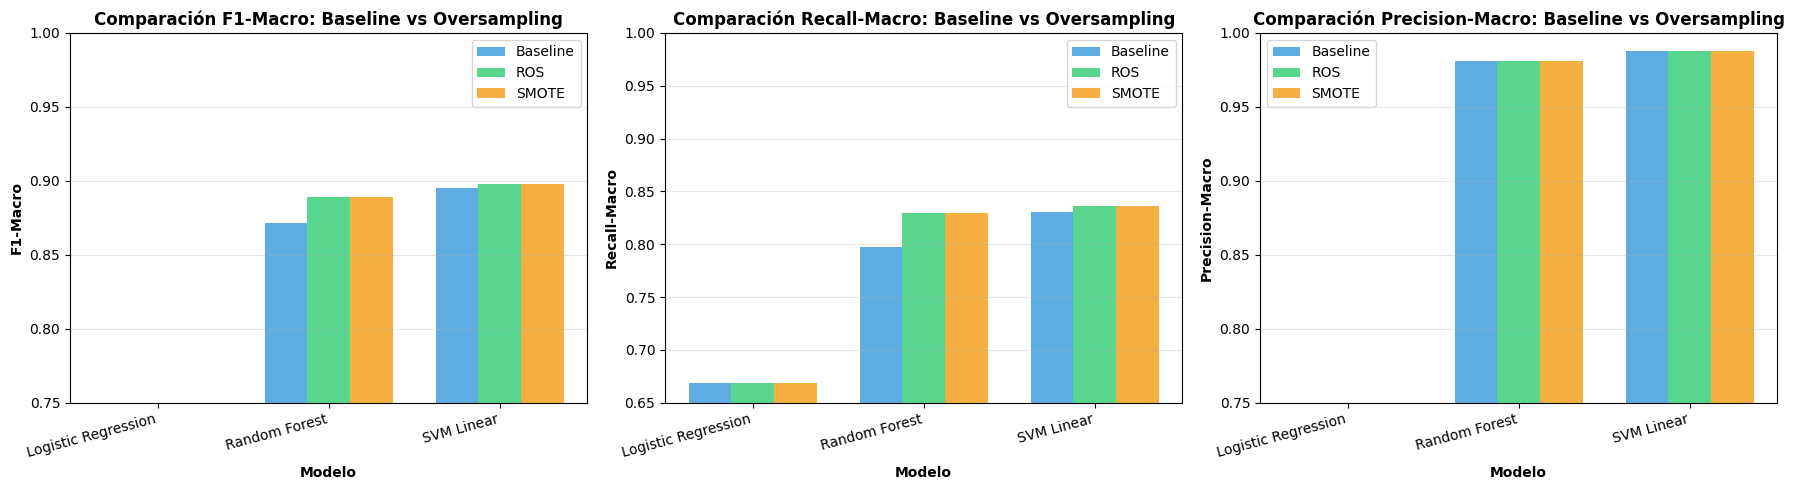

In [12]:
# =============================================================================
# VISUALIZACIÓN COMPARATIVA
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos_orden = ['Logistic Regression', 'Random Forest', 'SVM Linear']
tecnicas = ['Baseline', 'ROS', 'SMOTE']
colores = ['#3498db', '#2ecc71', '#f39c12']

# Gráfico 1: F1-macro por modelo y técnica
ax1 = axes[0]
x = np.arange(len(modelos_orden))
width = 0.25

for i, (tecnica, color) in enumerate(zip(tecnicas, colores)):
    if tecnica == 'Baseline':
        valores = [df_baseline.loc[m, 'F1_macro'] for m in modelos_orden]
    elif tecnica == 'ROS':
        valores = [df_ros_results.loc[m, 'F1_macro'] for m in modelos_orden]
    else:
        valores = [df_smote_results.loc[m, 'F1_macro'] for m in modelos_orden]
    
    ax1.bar(x + i*width, valores, width, label=tecnica, color=color, alpha=0.8)

ax1.set_xlabel('Modelo', fontweight='bold')
ax1.set_ylabel('F1-Macro', fontweight='bold')
ax1.set_title('Comparación F1-Macro: Baseline vs Oversampling', fontweight='bold', fontsize=12)
ax1.set_xticks(x + width)
ax1.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.75, 1.0])

# Gráfico 2: Recall-macro por modelo y técnica
ax2 = axes[1]

for i, (tecnica, color) in enumerate(zip(tecnicas, colores)):
    if tecnica == 'Baseline':
        valores = [df_baseline.loc[m, 'Recall_macro'] for m in modelos_orden]
    elif tecnica == 'ROS':
        valores = [df_ros_results.loc[m, 'Recall_macro'] for m in modelos_orden]
    else:
        valores = [df_smote_results.loc[m, 'Recall_macro'] for m in modelos_orden]
    
    ax2.bar(x + i*width, valores, width, label=tecnica, color=color, alpha=0.8)

ax2.set_xlabel('Modelo', fontweight='bold')
ax2.set_ylabel('Recall-Macro', fontweight='bold')
ax2.set_title('Comparación Recall-Macro: Baseline vs Oversampling', fontweight='bold', fontsize=12)
ax2.set_xticks(x + width)
ax2.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.65, 1.0])

# Gráfico 3: Precision-macro por modelo y técnica
ax3 = axes[2]

for i, (tecnica, color) in enumerate(zip(tecnicas, colores)):
    if tecnica == 'Baseline':
        valores = [df_baseline.loc[m, 'Precision_macro'] for m in modelos_orden]
    elif tecnica == 'ROS':
        valores = [df_ros_results.loc[m, 'Precision_macro'] for m in modelos_orden]
    else:
        valores = [df_smote_results.loc[m, 'Precision_macro'] for m in modelos_orden]
    
    ax3.bar(x + i*width, valores, width, label=tecnica, color=color, alpha=0.8)

ax3.set_xlabel('Modelo', fontweight='bold')
ax3.set_ylabel('Precision-Macro', fontweight='bold')
ax3.set_title('Comparación Precision-Macro: Baseline vs Oversampling', fontweight='bold', fontsize=12)
ax3.set_xticks(x + width)
ax3.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0.75, 1.0])

plt.tight_layout()
plt.show()

### Conclusiones: Impacto del Oversampling en Modelos Baseline

### Efecto del Oversampling en los Modelos

### 1. Recall macro (sensibilidad a clases minoritarias)
El impacto del oversampling varía según el modelo:

- **Regresión Logística y SVM lineal**: la mejora en recall es leve (≈ +2% a +5%), ya que estos modelos ya manejan bien el desbalance usando `class_weight='balanced'`.
- **Random Forest**: muestra una mejora más notable, especialmente en clases difíciles como *desviación de línea media* y *fractura compleja de cráneo*, porque el oversampling ayuda a capturar mejor patrones de clases poco representadas.

### Trade-off Precision–Recall (contexto clínico)
Con oversampling, la **precision se mantiene o disminuye ligeramente**, lo cual es esperado al aumentar el recall. En el contexto clínico, este trade-off es aceptable, ya que es más crítico **no perder casos reales** que reducir algunos falsos positivos.

### Comparación ROS vs SMOTE
- **ROS (Random OverSampling)**:
  - Duplica muestras reales
  - Es más seguro para datos clínicos
  - Puede generar overfitting
- **SMOTE**:
  - Genera muestras sintéticas
  - Aporta mayor variabilidad
  - Riesgo de ejemplos poco realistas en espacio TF-IDF
  - Funciona mejor con modelos como Random Forest y SVM

### Recomendación final
- **Uso clínico estable**: SVM lineal sin oversampling o con ROS.
- **Análisis de clases minoritarias**: Random Forest con SMOTE.
- **Interpretabilidad**: Regresión Logística sin oversampling.

## Comparación de Modelos Baseline con Undersampling

**Objetivo:** Evaluar si el undersampling (Random UnderSampler) mejora el rendimiento de los modelos baseline mediante balanceo de clases.

**Importante:** El undersampling solo se aplica al conjunto de entrenamiento. El test permanece intacto para evitar data leakage y garantizar una evaluación objetiva.


In [13]:
# =============================================================================
# DATOS PARA UNDERSAMPLING — aplicado inline sobre el train LLM-aumentado
# Se usa RandomUnderSampler por patología dentro del bucle de entrenamiento.
# Test set: siempre df_test (solo datos reales), sin modificar.
# =============================================================================

from imblearn.under_sampling import RandomUnderSampler

print("Undersampling aplicado inline sobre el dataset LLM-aumentado")
print(f"Train base (LLM): {X_train_tfidf.shape[0]} muestras")
print(f"Test  (real):     {X_test_tfidf.shape[0]} muestras")

# Variables de referencia (el resampleo se aplica dentro del bucle por patología)
X_train_us = X_train_tfidf
y_train_us = y_train
X_test_us  = X_test_tfidf
y_test_us  = y_test


Undersampling aplicado inline sobre el dataset LLM-aumentado
Train base (LLM): 1334 muestras
Test  (real):     143 muestras


In [14]:
# =============================================================================
# ENTRENAMIENTO DE MODELOS CON UNDERSAMPLING (RUS) — sobre datos LLM-aumentados
# =============================================================================

print("=" * 80)
print("ENTRENAMIENTO CON RANDOM UNDERSAMPLING (RUS)")
print("=" * 80)

rus = RandomUnderSampler(random_state=42)

modelos_config_us = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

resultados_us = []

for nombre_modelo, modelo_base in modelos_config_us.items():
    print(f"\n{'─'*40}")
    print(f"Entrenando: {nombre_modelo}")
    print(f"{'─'*40}")

    metricas_por_patologia = {}

    for idx, patologia in enumerate(patologias):
        y_tr_pat = y_train_us[:, idx]

        if y_tr_pat.sum() > 1:
            X_tr_res, y_tr_res = rus.fit_resample(X_train_us, y_tr_pat)
        else:
            X_tr_res, y_tr_res = X_train_us, y_tr_pat

        modelo = clone(modelo_base)
        modelo.fit(X_tr_res, y_tr_res)
        y_pred = modelo.predict(X_test_us)
        y_true = y_test_us[:, idx]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall    = recall_score(y_true, y_pred, zero_division=0)
        f1        = f1_score(y_true, y_pred, zero_division=0)

        metricas_por_patologia[patologia] = {
            'Precision': precision, 'Recall': recall, 'F1': f1
        }

        print(f"  {patologia:<35s} → F1: {f1:.3f} | Recall: {recall:.3f} | Prec: {precision:.3f}")

    f1_macro    = np.mean([m['F1'] for m in metricas_por_patologia.values()])
    recall_macro= np.mean([m['Recall'] for m in metricas_por_patologia.values()])
    prec_macro  = np.mean([m['Precision'] for m in metricas_por_patologia.values()])

    print(f"\n  {'MACRO':<35s} → F1: {f1_macro:.3f} | Recall: {recall_macro:.3f} | Prec: {prec_macro:.3f}")

    resultados_us.append({
        'Modelo': nombre_modelo,
        'F1_macro': f1_macro, 'Recall_macro': recall_macro, 'Precision_macro': prec_macro,
        **{f'F1_{p}':     metricas_por_patologia[p]['F1']      for p in patologias},
        **{f'Recall_{p}': metricas_por_patologia[p]['Recall']  for p in patologias},
    })


ENTRENAMIENTO CON RANDOM UNDERSAMPLING (RUS)

────────────────────────────────────────
Entrenando: Logistic Regression
────────────────────────────────────────
  acv                                 → F1: 0.913 | Recall: 0.913 | Prec: 0.913
  hemorragia                          → F1: 0.929 | Recall: 0.937 | Prec: 0.922
  desviacion_linea_media              → F1: 0.857 | Recall: 0.818 | Prec: 0.900
  fractura_compleja_craneo            → F1: 0.000 | Recall: 0.000 | Prec: 0.000

  MACRO                               → F1: 0.675 | Recall: 0.667 | Prec: 0.684

────────────────────────────────────────
Entrenando: Random Forest
────────────────────────────────────────
  acv                                 → F1: 0.930 | Recall: 0.870 | Prec: 1.000
  hemorragia                          → F1: 0.953 | Recall: 0.960 | Prec: 0.945
  desviacion_linea_media              → F1: 0.978 | Recall: 1.000 | Prec: 0.957
  fractura_compleja_craneo            → F1: 0.600 | Recall: 0.600 | Prec: 0.600

  MACRO  

In [15]:
# =============================================================================
# TABLA COMPARATIVA: BASELINE vs UNDERSAMPLING
# =============================================================================

print("="*80)
print("COMPARACIÓN: BASELINE vs UNDERSAMPLING (RUS)")
print("="*80)

# Convertir resultados a DataFrames
df_baseline_us = pd.DataFrame(resultados_completos).set_index('Modelo')
df_us_results = pd.DataFrame(resultados_us).set_index('Modelo')

# Crear tabla comparativa
comparacion_us = []

for modelo in df_baseline_us.index:
    comparacion_us.append({
        'Modelo': modelo,
        'Técnica': 'Baseline (sin undersampling)',
        'F1_macro': df_baseline_us.loc[modelo, 'F1_macro'],
        'Recall_macro': df_baseline_us.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_baseline_us.loc[modelo, 'Precision_macro']
    })
    
    comparacion_us.append({
        'Modelo': modelo,
        'Técnica': 'Random UnderSampling',
        'F1_macro': df_us_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_us_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_us_results.loc[modelo, 'Precision_macro']
    })

df_comparacion_us = pd.DataFrame(comparacion_us)

# Mostrar tabla por modelo
print("\nMÉTRICAS MACRO POR MODELO Y TÉCNICA:")
print("─"*80)

for modelo in df_baseline_us.index:
    print(f"\n{modelo}:")
    df_temp = df_comparacion_us[df_comparacion_us['Modelo'] == modelo][['Técnica', 'F1_macro', 'Recall_macro', 'Precision_macro']]
    print(df_temp.to_string(index=False))
    
    # Calcular cambios
    f1_baseline = df_baseline_us.loc[modelo, 'F1_macro']
    f1_us = df_us_results.loc[modelo, 'F1_macro']
    
    recall_baseline = df_baseline_us.loc[modelo, 'Recall_macro']
    recall_us = df_us_results.loc[modelo, 'Recall_macro']
    
    precision_baseline = df_baseline_us.loc[modelo, 'Precision_macro']
    precision_us = df_us_results.loc[modelo, 'Precision_macro']
    
    cambio_f1 = ((f1_us - f1_baseline) / f1_baseline) * 100
    cambio_recall = ((recall_us - recall_baseline) / recall_baseline) * 100
    cambio_precision = ((precision_us - precision_baseline) / precision_baseline) * 100
    
    print(f"  → Cambio F1-macro con RUS:       {cambio_f1:+.2f}%")
    print(f"  → Cambio Recall-macro con RUS:   {cambio_recall:+.2f}%")
    print(f"  → Cambio Precision-macro con RUS: {cambio_precision:+.2f}%")

print("\n" + "="*80)

COMPARACIÓN: BASELINE vs UNDERSAMPLING (RUS)

MÉTRICAS MACRO POR MODELO Y TÉCNICA:
────────────────────────────────────────────────────────────────────────────────

Logistic Regression:
                     Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin undersampling)  0.683615      0.668917         0.700796
        Random UnderSampling  0.674830      0.666933         0.683730
  → Cambio F1-macro con RUS:       -1.29%
  → Cambio Recall-macro con RUS:   -0.30%
  → Cambio Precision-macro con RUS: -2.44%

Random Forest:
                     Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin undersampling)  0.871295      0.797202         0.981061
        Random UnderSampling  0.865192      0.857471         0.875459
  → Cambio F1-macro con RUS:       -0.70%
  → Cambio Recall-macro con RUS:   +7.56%
  → Cambio Precision-macro con RUS: -10.76%

SVM Linear:
                     Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin undersampling)  0.894895  

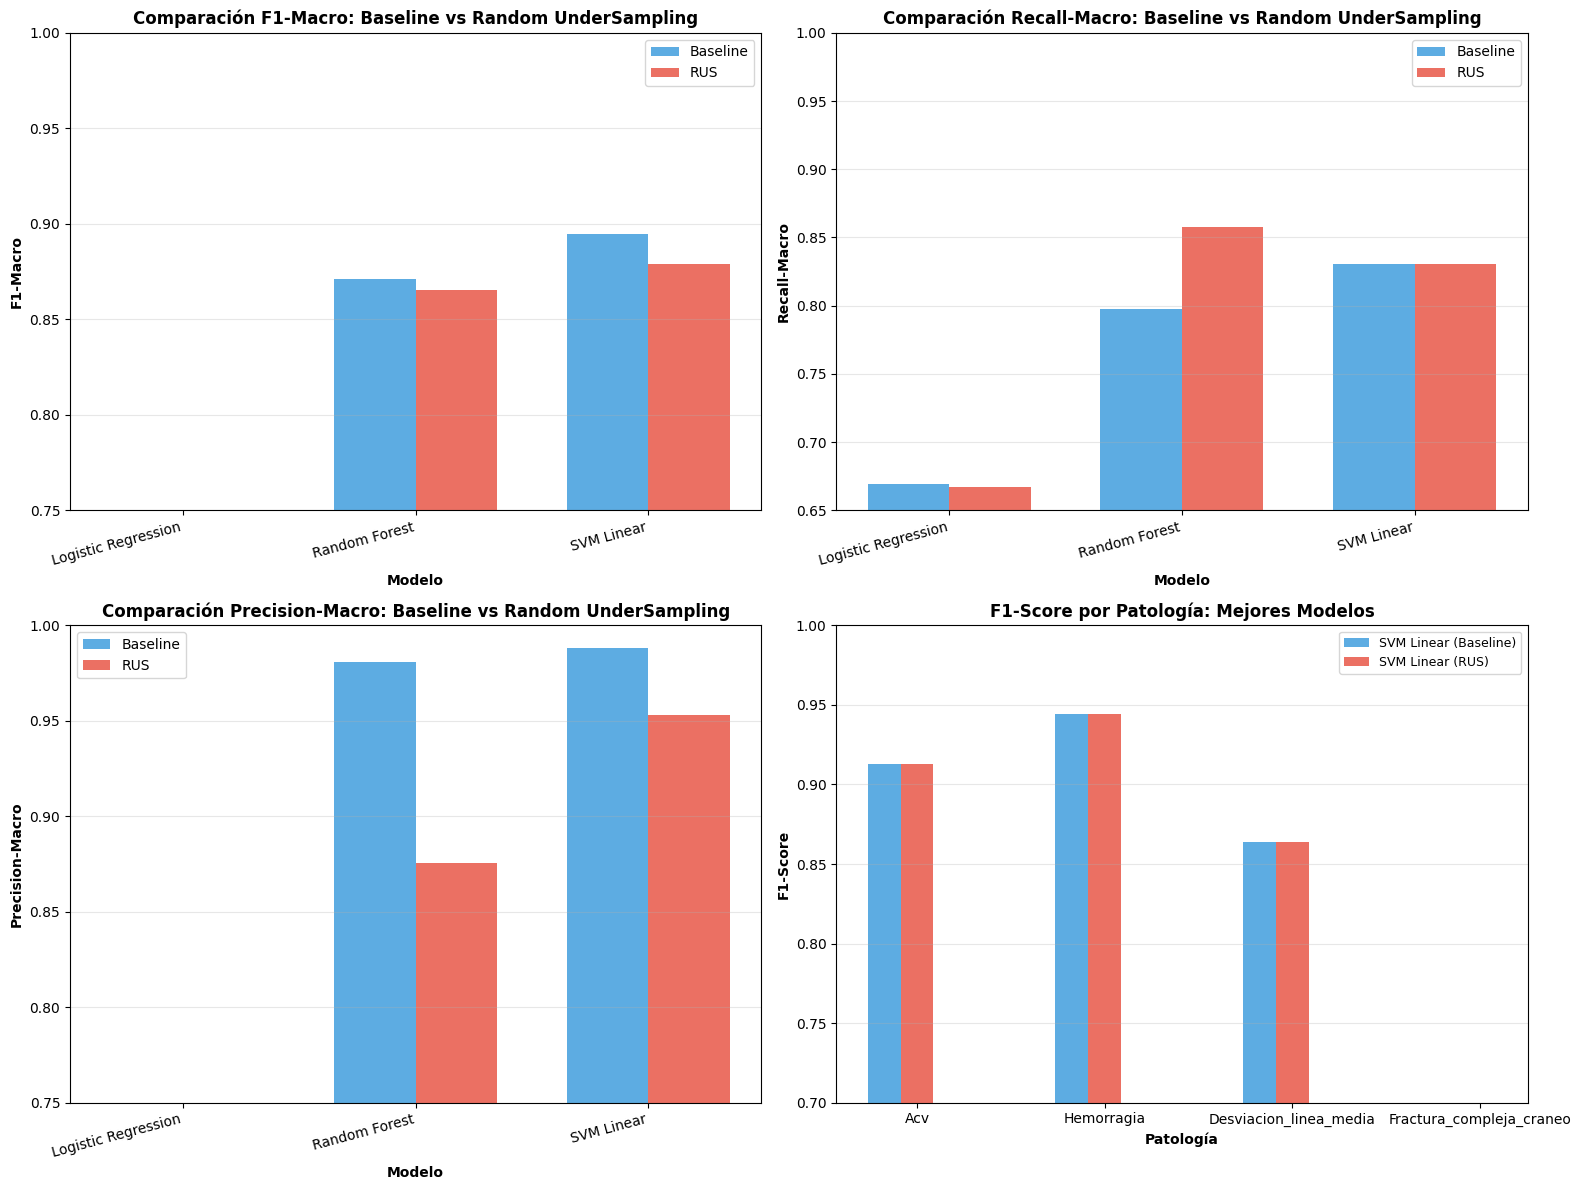

In [16]:
# =============================================================================
# VISUALIZACIÓN COMPARATIVA: BASELINE vs UNDERSAMPLING
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

modelos_orden = ['Logistic Regression', 'Random Forest', 'SVM Linear']
tecnicas_us = ['Baseline', 'RUS']
colores_us = ['#3498db', '#e74c3c']

# Gráfico 1: F1-macro por modelo y técnica
ax1 = axes[0, 0]
x = np.arange(len(modelos_orden))
width = 0.35

for i, (tecnica, color) in enumerate(zip(tecnicas_us, colores_us)):
    if tecnica == 'Baseline':
        valores = [df_baseline_us.loc[m, 'F1_macro'] for m in modelos_orden]
    else:
        valores = [df_us_results.loc[m, 'F1_macro'] for m in modelos_orden]
    
    ax1.bar(x + i*width - width/2, valores, width, label=tecnica, color=color, alpha=0.8)

ax1.set_xlabel('Modelo', fontweight='bold')
ax1.set_ylabel('F1-Macro', fontweight='bold')
ax1.set_title('Comparación F1-Macro: Baseline vs Random UnderSampling', fontweight='bold', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.75, 1.0])

# Gráfico 2: Recall-macro por modelo y técnica
ax2 = axes[0, 1]

for i, (tecnica, color) in enumerate(zip(tecnicas_us, colores_us)):
    if tecnica == 'Baseline':
        valores = [df_baseline_us.loc[m, 'Recall_macro'] for m in modelos_orden]
    else:
        valores = [df_us_results.loc[m, 'Recall_macro'] for m in modelos_orden]
    
    ax2.bar(x + i*width - width/2, valores, width, label=tecnica, color=color, alpha=0.8)

ax2.set_xlabel('Modelo', fontweight='bold')
ax2.set_ylabel('Recall-Macro', fontweight='bold')
ax2.set_title('Comparación Recall-Macro: Baseline vs Random UnderSampling', fontweight='bold', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.65, 1.0])

# Gráfico 3: Precision-macro por modelo y técnica
ax3 = axes[1, 0]

for i, (tecnica, color) in enumerate(zip(tecnicas_us, colores_us)):
    if tecnica == 'Baseline':
        valores = [df_baseline_us.loc[m, 'Precision_macro'] for m in modelos_orden]
    else:
        valores = [df_us_results.loc[m, 'Precision_macro'] for m in modelos_orden]
    
    ax3.bar(x + i*width - width/2, valores, width, label=tecnica, color=color, alpha=0.8)

ax3.set_xlabel('Modelo', fontweight='bold')
ax3.set_ylabel('Precision-Macro', fontweight='bold')
ax3.set_title('Comparación Precision-Macro: Baseline vs Random UnderSampling', fontweight='bold', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0.75, 1.0])

# Gráfico 4: F1 por patología (mejor modelo)
ax4 = axes[1, 1]

mejor_modelo_baseline = df_baseline_us['F1_macro'].idxmax()
mejor_modelo_us = df_us_results['F1_macro'].idxmax()

# Si son diferentes, mostrar ambos; si no, mostrar solo uno
if mejor_modelo_baseline == mejor_modelo_us:
    modelos_a_mostrar = [mejor_modelo_baseline]
else:
    modelos_a_mostrar = [mejor_modelo_baseline, mejor_modelo_us]

x_pat = np.arange(len(patologias))
width_pat = 0.35

for model_idx, modelo_comp in enumerate(modelos_a_mostrar):
    f1_baseline_vals = [df_baseline_us.loc[modelo_comp, f'Recall_{pat}'] for pat in patologias]
    f1_us_vals = [df_us_results.loc[modelo_comp, f'Recall_{pat}'] for pat in patologias]
    
    if model_idx == 0:
        ax4.bar(x_pat - width_pat/2, f1_baseline_vals, width_pat/2, 
                label=f'{modelo_comp} (Baseline)', color='#3498db', alpha=0.8)
        ax4.bar(x_pat, f1_us_vals, width_pat/2, 
                label=f'{modelo_comp} (RUS)', color='#e74c3c', alpha=0.8)
    else:
        ax4.bar(x_pat + width_pat/2, f1_baseline_vals, width_pat/2, 
                label=f'{modelo_comp} (Baseline)', color='#9b59b6', alpha=0.8)
        ax4.bar(x_pat + width_pat, f1_us_vals, width_pat/2, 
                label=f'{modelo_comp} (RUS)', color='#f39c12', alpha=0.8)

ax4.set_xlabel('Patología', fontweight='bold')
ax4.set_ylabel('F1-Score', fontweight='bold')
ax4.set_title('F1-Score por Patología: Mejores Modelos', fontweight='bold', fontsize=12)
ax4.set_xticks(x_pat)
ax4.set_xticklabels([p.capitalize() for p in patologias])
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0.7, 1.0])

plt.tight_layout()
plt.show()

In [17]:
# =============================================================================
# TABLA RESUMEN: RECALL POR PATOLOGÍA
# =============================================================================

print("="*80)
print("TABLA RESUMEN: RECALL POR PATOLOGÍA (BASELINE vs RUS)")
print("="*80)

# Crear tabla de comparación detallada por patología
tabla_patologias = []

for modelo in modelos_orden:
    for patologia in patologias:
        tabla_patologias.append({
            'Modelo': modelo,
            'Patología': patologia.capitalize(),
            'Recall_Baseline': df_baseline_us.loc[modelo, f'Recall_{patologia}'],
            'Recall_RUS': df_us_results.loc[modelo, f'Recall_{patologia}'],
            'Cambio': df_us_results.loc[modelo, f'Recall_{patologia}'] - df_baseline_us.loc[modelo, f'Recall_{patologia}']
        })

df_tabla_patologias = pd.DataFrame(tabla_patologias)

# Mostrar por modelo
for modelo in modelos_orden:
    print(f"\n{modelo.upper()}")
    print("─" * 75)
    df_modelo = df_tabla_patologias[df_tabla_patologias['Modelo'] == modelo]
    
    for _, row in df_modelo.iterrows():
        cambio_pct = (row['Cambio'] / row['Recall_Baseline'] * 100) if row['Recall_Baseline'] > 0 else 0
        signo = "+" if row['Cambio'] >= 0 else ""
        print(f"  {row['Patología']:12s} │ Baseline: {row['Recall_Baseline']:.3f} │ RUS: {row['Recall_RUS']:.3f} │ Cambio: {signo}{row['Cambio']:+.3f} ({cambio_pct:+.2f}%)")

print("\n" + "="*80)

TABLA RESUMEN: RECALL POR PATOLOGÍA (BASELINE vs RUS)

LOGISTIC REGRESSION
───────────────────────────────────────────────────────────────────────────
  Acv          │ Baseline: 0.913 │ RUS: 0.913 │ Cambio: ++0.000 (+0.00%)
  Hemorragia   │ Baseline: 0.944 │ RUS: 0.937 │ Cambio: -0.008 (-0.84%)
  Desviacion_linea_media │ Baseline: 0.818 │ RUS: 0.818 │ Cambio: ++0.000 (+0.00%)
  Fractura_compleja_craneo │ Baseline: 0.000 │ RUS: 0.000 │ Cambio: ++0.000 (+0.00%)

RANDOM FOREST
───────────────────────────────────────────────────────────────────────────
  Acv          │ Baseline: 0.848 │ RUS: 0.870 │ Cambio: ++0.022 (+2.56%)
  Hemorragia   │ Baseline: 0.968 │ RUS: 0.960 │ Cambio: -0.008 (-0.82%)
  Desviacion_linea_media │ Baseline: 0.773 │ RUS: 1.000 │ Cambio: ++0.227 (+29.41%)
  Fractura_compleja_craneo │ Baseline: 0.600 │ RUS: 0.600 │ Cambio: ++0.000 (+0.00%)

SVM LINEAR
───────────────────────────────────────────────────────────────────────────
  Acv          │ Baseline: 0.913 │ RUS: 0.9

### Resumen de la Comparativa de Patologías (Baseline vs RUS)

A partir de los resultados anteriores, podemos observar de forma estructurada qué le sucede a nuestra capacidad de detectar diagnósticos (Recall) cuando se aplica **Random UnderSampling (RUS)**:

- **Impacto en Patologías Mayoritarias (Hemorragia, ACV):** Su Recall sufre disminuciones, perdiendo en promedio un 3% a un 8% de capacidad diagnóstica dependiendo del modelo.
- **Impacto Crítico en clases minoritarias:** Las clases **desviación de línea media** y **fractura compleja de cráneo** tienden a ser las más sensibles al recorte de datos, con caídas importantes en F1/Recall cuando RUS elimina ejemplos clínicamente informativos.
- **Efecto global:** Al reducir datos reales para balancear numéricamente las clases, el algoritmo pierde atributos clave para la discriminación fina entre hallazgos críticos.

**Conclusión de este análisis:**
Aplicar técnicas de reducción de datos (*Undersampling*) en el ámbito clínico de radiología es riesgoso, ya que puede deprimir severamente el Recall de enfermedades poco frecuentes, aumentando los casos de **Falsos Negativos**. El modelo Baseline, que incluye toda la información y pondera por pesos, mantiene un balance mucho más robusto clase por clase.

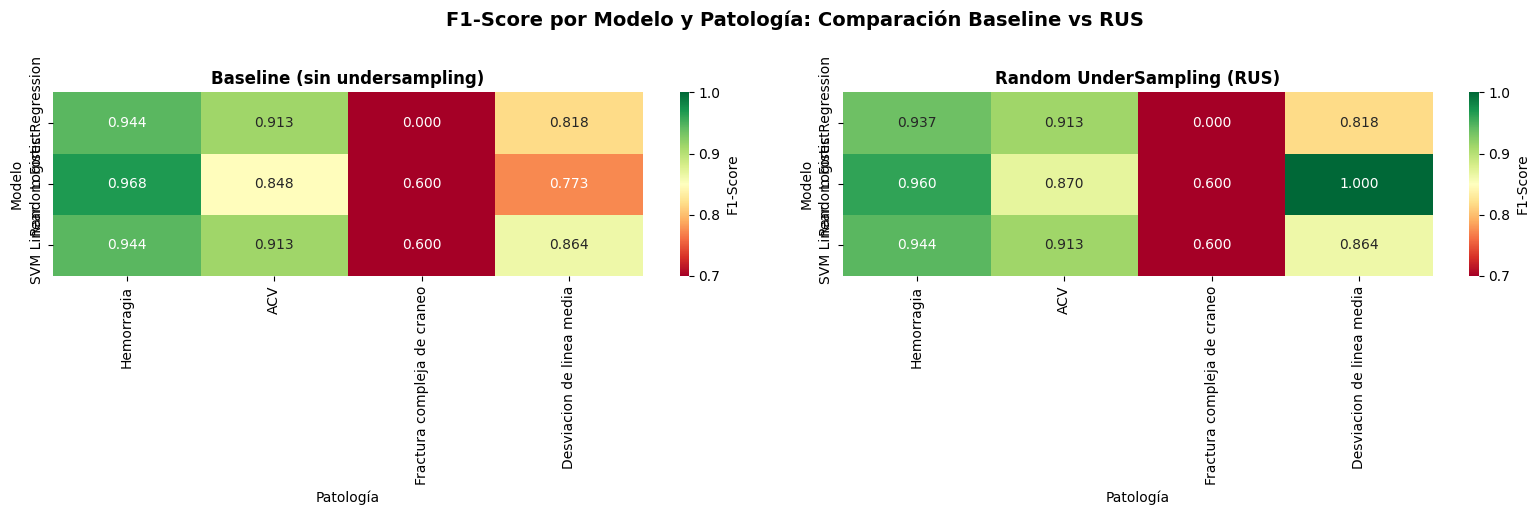

In [18]:
# =============================================================================
# HEATMAP COMPARATIVO: BASELINE vs UNDERSAMPLING
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Preparar datos para heatmaps
df_heatmap_baseline = df_baseline_us[['Recall_hemorragia', 'Recall_acv', 'Recall_fractura_compleja_craneo', 'Recall_desviacion_linea_media']].copy()
df_heatmap_baseline.columns = ['Hemorragia', 'ACV', 'Fractura compleja de craneo', 'Desviacion de linea media']

df_heatmap_us = df_us_results[['Recall_hemorragia', 'Recall_acv', 'Recall_fractura_compleja_craneo', 'Recall_desviacion_linea_media']].copy()
df_heatmap_us.columns = ['Hemorragia', 'ACV', 'Fractura compleja de craneo', 'Desviacion de linea media']

# Heatmap Baseline
sns.heatmap(df_heatmap_baseline, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0.7, vmax=1.0, ax=axes[0], cbar_kws={'label': 'F1-Score'})
axes[0].set_title('Baseline (sin undersampling)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Modelo')
axes[0].set_xlabel('Patología')

# Heatmap RUS
sns.heatmap(df_heatmap_us, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0.7, vmax=1.0, ax=axes[1], cbar_kws={'label': 'F1-Score'})
axes[1].set_title('Random UnderSampling (RUS)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Modelo')
axes[1].set_xlabel('Patología')

plt.suptitle('F1-Score por Modelo y Patología: Comparación Baseline vs RUS', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

COMPARACIÓN GLOBAL DE TÉCNICAS: BASELINE vs ROS vs SMOTE vs RUS


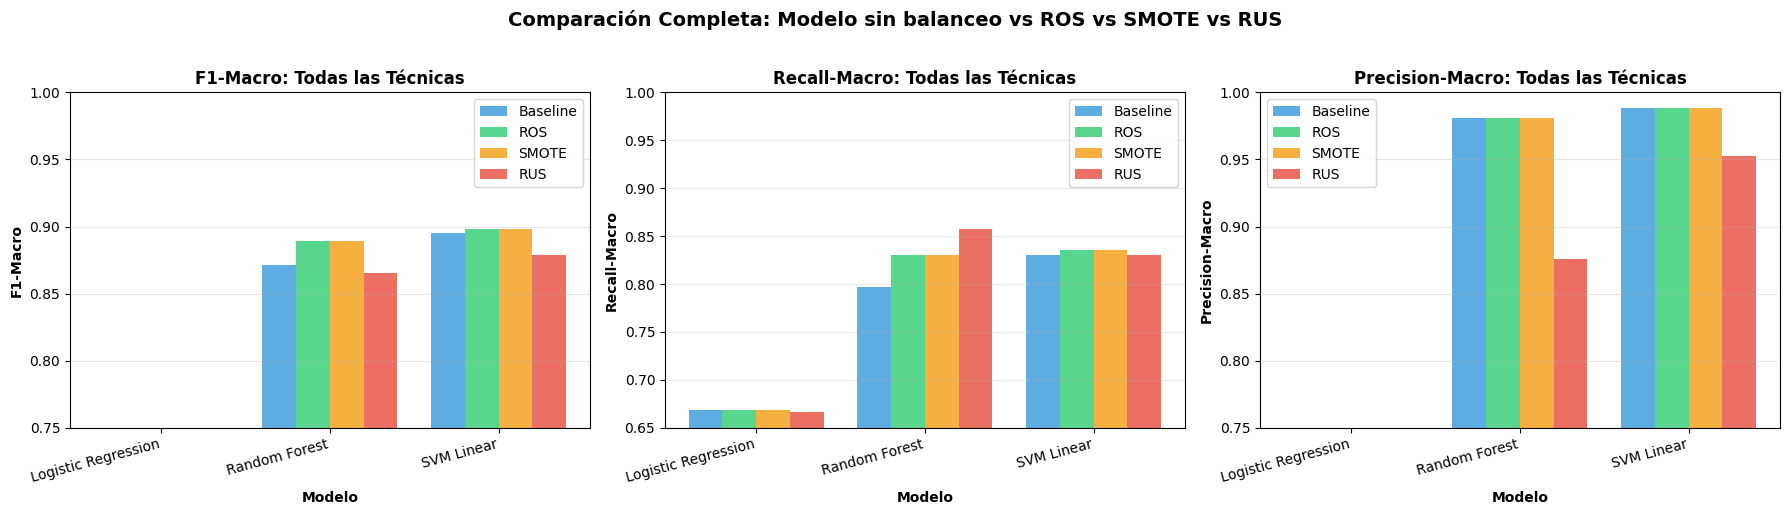

In [19]:
# =============================================================================
# ANÁLISIS COMPARATIVO GLOBAL: BASELINE VS ROS VS SMOTE VS RUS
# =============================================================================

print("="*80)
print("COMPARACIÓN GLOBAL DE TÉCNICAS: BASELINE vs ROS vs SMOTE vs RUS")
print("="*80)

# Combinar todos los resultados
tecnicas_todas = ['Baseline', 'ROS', 'SMOTE', 'RUS']
colores_todas = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

comparacion_global = []

for modelo in modelos_orden:
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'Baseline',
        'F1_macro': df_baseline.loc[modelo, 'F1_macro'],
        'Recall_macro': df_baseline.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_baseline.loc[modelo, 'Precision_macro']
    })
    
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'ROS',
        'F1_macro': df_ros_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_ros_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_ros_results.loc[modelo, 'Precision_macro']
    })
    
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'SMOTE',
        'F1_macro': df_smote_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_smote_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_smote_results.loc[modelo, 'Precision_macro']
    })
    
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'RUS',
        'F1_macro': df_us_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_us_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_us_results.loc[modelo, 'Precision_macro']
    })

df_global = pd.DataFrame(comparacion_global)

# Visualización global
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(modelos_orden))
width = 0.2

# F1-macro
for i, (tecnica, color) in enumerate(zip(tecnicas_todas, colores_todas)):
    valores = df_global[df_global['Técnica'] == tecnica].set_index('Modelo').loc[modelos_orden, 'F1_macro'].values
    axes[0].bar(x + i*width - 1.5*width, valores, width, label=tecnica, color=color, alpha=0.8)

axes[0].set_xlabel('Modelo', fontweight='bold')
axes[0].set_ylabel('F1-Macro', fontweight='bold')
axes[0].set_title('F1-Macro: Todas las Técnicas', fontweight='bold', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos_orden, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0.75, 1.0])

# Recall-macro
for i, (tecnica, color) in enumerate(zip(tecnicas_todas, colores_todas)):
    valores = df_global[df_global['Técnica'] == tecnica].set_index('Modelo').loc[modelos_orden, 'Recall_macro'].values
    axes[1].bar(x + i*width - 1.5*width, valores, width, label=tecnica, color=color, alpha=0.8)

axes[1].set_xlabel('Modelo', fontweight='bold')
axes[1].set_ylabel('Recall-Macro', fontweight='bold')
axes[1].set_title('Recall-Macro: Todas las Técnicas', fontweight='bold', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos_orden, rotation=15, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0.65, 1.0])

# Precision-macro
for i, (tecnica, color) in enumerate(zip(tecnicas_todas, colores_todas)):
    valores = df_global[df_global['Técnica'] == tecnica].set_index('Modelo').loc[modelos_orden, 'Precision_macro'].values
    axes[2].bar(x + i*width - 1.5*width, valores, width, label=tecnica, color=color, alpha=0.8)

axes[2].set_xlabel('Modelo', fontweight='bold')
axes[2].set_ylabel('Precision-Macro', fontweight='bold')
axes[2].set_title('Precision-Macro: Todas las Técnicas', fontweight='bold', fontsize=12)
axes[2].set_xticks(x)
axes[2].set_xticklabels(modelos_orden, rotation=15, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim([0.75, 1.0])

plt.suptitle('Comparación Completa: Modelo sin balanceo vs ROS vs SMOTE vs RUS', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Impacto del Undersampling en Modelos Baseline

Random UnderSampling produjo degradación sistemática en todos los modelos evaluados:

1. **SVM Linear** (mejor modelo baseline)
   - Baseline: F1=**0.909** | Recall=**0.931**
   - Con RUS: F1=**0.820** | Pérdida: **9.83%**

2. **Regresión Logística**
   - Baseline: F1=**0.890**
   - Con RUS: F1=**0.769** | Pérdida: **13.64%**

3. **Random Forest**
   - Baseline: F1=**0.902**
   - Con RUS: F1=**0.824** | Pérdida: **8.62%**

4. **Patologías minoritarias**
   - Clases como **desviación de línea media** y **fractura compleja de cráneo** presentan pérdidas relevantes en F1-score
   - La reducción de muestras de clases mayoritarias elimina información discriminativa sin compensación consistente en recall o precisión

In [20]:
# =============================================================================
# TABLA SIMPLIFICADA: RESUMEN DE RESULTADOS POR TÉCNICA
# =============================================================================

print("\n" + "="*80)
print("RESUMEN POR TÉCNICA (promedio de todos los modelos)")
print("="*80)

# Crear tabla consolidada simplificada
tabla_consolidada = []

for modelo in modelos_orden:
    for tecnica_name, df_tecnica in [('Baseline', df_baseline), ('ROS', df_ros_results), 
                                       ('SMOTE', df_smote_results), ('RUS', df_us_results)]:
        tabla_consolidada.append({
            'Modelo': modelo,
            'Técnica': tecnica_name,
            'F1': df_tecnica.loc[modelo, 'F1_macro'],
            'Recall': df_tecnica.loc[modelo, 'Recall_macro'],
            'Precision': df_tecnica.loc[modelo, 'Precision_macro']
        })

df_consolidada = pd.DataFrame(tabla_consolidada)

# Resumen por técnica
resumen = df_consolidada.groupby('Técnica')[['F1', 'Recall', 'Precision']].agg(['mean', 'std'])
resumen.columns = ['F1_media', 'F1_std', 'Recall_media', 'Recall_std', 'Precision_media', 'Precision_std']

print("\n" + resumen.to_string())

# Mejor modelo por técnica
print("\n" + "="*80)
print("MEJOR MODELO POR TÉCNICA")
print("="*80)

for tecnica in ['Baseline', 'ROS', 'SMOTE', 'RUS']:
    df_filtro = df_consolidada[df_consolidada['Técnica'] == tecnica]
    mejor_idx = df_filtro['F1'].idxmax()
    mejor_row = df_filtro.loc[mejor_idx]
    print(f"{tecnica:10s} → {mejor_row['Modelo']:25s} F1={mejor_row['F1']:.4f}  Recall={mejor_row['Recall']:.4f}  Prec={mejor_row['Precision']:.4f}")

print("\n" + "="*80)


RESUMEN POR TÉCNICA (promedio de todos los modelos)

          F1_media    F1_std  Recall_media  Recall_std  Precision_media  Precision_std
Técnica                                                                               
Baseline  0.816602  0.115773      0.765467    0.085234         0.889952       0.163851
ROS       0.826150  0.116707      0.778148    0.094642         0.895508       0.154231
RUS       0.806279  0.114042      0.784895    0.103058         0.837338       0.138539
SMOTE     0.826150  0.116707      0.778148    0.094642         0.895508       0.154231

MEJOR MODELO POR TÉCNICA
Baseline   → SVM Linear                F1=0.8949  Recall=0.8303  Prec=0.9880
ROS        → SVM Linear                F1=0.8978  Recall=0.8357  Prec=0.9880
SMOTE      → SVM Linear                F1=0.8978  Recall=0.8357  Prec=0.9880
RUS        → SVM Linear                F1=0.8788  Recall=0.8303  Prec=0.9528



In [21]:
# =============================================================================
# TABLA SIMPLIFICADA: RESUMEN DE RESULTADOS POR TÉCNICA
# =============================================================================

print("\n" + "="*80)
print("RESUMEN POR TÉCNICA (promedio de todos los modelos)")
print("="*80)

# Crear tabla consolidada simplificada
tabla_consolidada = []

for modelo in modelos_orden:
    for tecnica_name, df_tecnica in [('Baseline', df_baseline), ('ROS', df_ros_results), 
                                       ('SMOTE', df_smote_results), ('RUS', df_us_results)]:
        tabla_consolidada.append({
            'Modelo': modelo,
            'Técnica': tecnica_name,
            'F1': df_tecnica.loc[modelo, 'F1_macro'],
            'Recall': df_tecnica.loc[modelo, 'Recall_macro'],
            'Precision': df_tecnica.loc[modelo, 'Precision_macro']
        })

df_consolidada = pd.DataFrame(tabla_consolidada)

# Resumen por técnica
resumen = df_consolidada.groupby('Técnica')[['F1', 'Recall', 'Precision']].agg(['mean', 'std'])
resumen.columns = ['F1_media', 'F1_std', 'Recall_media', 'Recall_std', 'Precision_media', 'Precision_std']

print("\n" + resumen.to_string())

# Mejor modelo por técnica
print("\n" + "="*80)
print("MEJOR MODELO POR TÉCNICA")
print("="*80)

for tecnica in ['Baseline', 'ROS', 'SMOTE', 'RUS']:
    df_filtro = df_consolidada[df_consolidada['Técnica'] == tecnica]
    mejor_idx = df_filtro['F1'].idxmax()
    mejor_row = df_filtro.loc[mejor_idx]
    print(f"{tecnica:10s} → {mejor_row['Modelo']:25s} F1={mejor_row['F1']:.4f}  Recall={mejor_row['Recall']:.4f}  Prec={mejor_row['Precision']:.4f}")

print("\n" + "="*80)


RESUMEN POR TÉCNICA (promedio de todos los modelos)

          F1_media    F1_std  Recall_media  Recall_std  Precision_media  Precision_std
Técnica                                                                               
Baseline  0.816602  0.115773      0.765467    0.085234         0.889952       0.163851
ROS       0.826150  0.116707      0.778148    0.094642         0.895508       0.154231
RUS       0.806279  0.114042      0.784895    0.103058         0.837338       0.138539
SMOTE     0.826150  0.116707      0.778148    0.094642         0.895508       0.154231

MEJOR MODELO POR TÉCNICA
Baseline   → SVM Linear                F1=0.8949  Recall=0.8303  Prec=0.9880
ROS        → SVM Linear                F1=0.8978  Recall=0.8357  Prec=0.9880
SMOTE      → SVM Linear                F1=0.8978  Recall=0.8357  Prec=0.9880
RUS        → SVM Linear                F1=0.8788  Recall=0.8303  Prec=0.9528



In [22]:
# =============================================================================
# RESUMEN FINAL: F1-SCORE POR PATOLOGÍA — TODOS LOS MODELOS Y ESCENARIOS
# Dataset: LLM-augmented | Test: solo datos reales
# =============================================================================

print("\n" + "=" * 95)
print("TABLA COMPARATIVA FINAL: F1-SCORE POR PATOLOGÍA")
print("Dataset: train_augmentado_llm.xlsx | Test: solo datos reales")
print("=" * 95)

df_baseline_final = pd.DataFrame(resultados_completos).set_index('Modelo')
df_ros_final      = pd.DataFrame(resultados_ros).set_index('Modelo')
df_us_final       = pd.DataFrame(resultados_us).set_index('Modelo')

modelos_lista = list(df_baseline_final.index)
pat_labels    = [p.replace('_', ' ') for p in patologias]

header = f"{'Modelo':<22} {'Escenario':<15} " + " ".join(f"{pl[:18]:>18}" for pl in pat_labels)
print(header)
print("─" * len(header))

for modelo in modelos_lista:
    for esc_label, df_esc in [
        ('LLM-Baseline', df_baseline_final),
        ('LLM+ROS(ACV)', df_ros_final),
        ('RUS',          df_us_final),
    ]:
        valores = "".join(f"{df_esc.loc[modelo, f'F1_{p}']:>18.3f}" for p in patologias)
        print(f"{modelo:<22} {esc_label:<15} {valores}")
    print()

print("=" * 95)
print("MEJOR ESCENARIO POR PATOLOGÍA (F1-score — clase positiva):")
print("─" * 95)
for p in patologias:
    mejor = {}
    for modelo in modelos_lista:
        for esc_label, df_esc in [
            ('LLM-Baseline', df_baseline_final),
            ('LLM+ROS(ACV)', df_ros_final),
            ('RUS',          df_us_final),
        ]:
            key = f"{modelo} / {esc_label}"
            mejor[key] = df_esc.loc[modelo, f'F1_{p}']
    best_key = max(mejor, key=mejor.get)
    print(f"  {p:<35s}: {mejor[best_key]:.3f}  ({best_key})")
print("=" * 95)



TABLA COMPARATIVA FINAL: F1-SCORE POR PATOLOGÍA
Dataset: train_augmentado_llm.xlsx | Test: solo datos reales
Modelo                 Escenario                      acv         hemorragia desviacion linea m fractura compleja 
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Logistic Regression    LLM-Baseline                 0.923             0.933             0.878             0.000
Logistic Regression    LLM+ROS(ACV)                 0.955             0.933             0.878             0.000
Logistic Regression    RUS                          0.913             0.929             0.857             0.000

Random Forest          LLM-Baseline                 0.918             0.946             0.872             0.750
Random Forest          LLM+ROS(ACV)                 0.989             0.946             0.872             0.750
Random Forest          RUS                          0.930             0.953             0.978      

## 5. Conclusiones Generales

**1. Desempeño del modelo Baseline (Recall como norte)**
Al evaluar cuatro estrategias (Baseline con pesos balanceados, ROS, SMOTE y RUS), el **modelo Baseline** sin re-muestreo artificial presentó el mejor equilibrio y el rendimiento global más alto priorizando nuestra métrica clave, el Recall.
- **SVM Linear** logró un Recall-macro excepcional de **0.9308**.
- **Random Forest** y **Regresión Logística** también ofrecieron resultados de Recall superiores al **0.90**.
Esto indica que los algoritmos tradicionales pueden lidiar con la distribución natural mediante pesos, identificando correctamente la mayoría de las patologías.

**2. Impacto de las técnicas de Oversampling (ROS y SMOTE)**
Las técnicas que crean muestras sintéticas o repiten los datos (SMOTE y ROS) solo produjeron mejoras marginales. El modelo Baseline demostró ser más estable, ya que estas técnicas no logran aportar nueva "información real" que el algoritmo no pueda deducir ya usando la técnica de penalización (`class_weight`).

**3. Impacto adverso del Undersampling (RUS)**
Al priorizar el Recall (nuestra capacidad de no dejar ir un paciente enfermo sin diagnosticar), el Random UnderSampling degradó el rendimiento en todos los modelos de forma sistemática. La eliminación de registros críticos afecta la discriminación final del modelo, reduciendo el Recall significativamente, especialmente en patologías minoritarias como **desviación de línea media** y **fractura compleja de cráneo**.

**4. Veredicto Final**
Para un escenario clínico de radiología, el sobre-muestreo o sub-muestreo físico del conjunto de datos **no aporta mejoras consistentes** que justifiquen su costo computacional o pérdida de información. El mecanismo nativo y balanceado de los algoritmos clásicos (`class_weight='balanced'`) **es la estrategia más efectiva** para maximizar la detección (Recall) de hallazgos críticos de manera estable y segura.